# **lab1**


# Laboratory Work 1 — UR5

## Objective
The objective of this work is to load the UR5 manipulator model, display its Denavit–Hartenberg parameters and dynamic parameters, define initial and final joint configurations, plan a trajectory, solve the inverse dynamics problem using the Newton–Euler method for three scenarios, compute the matrices $M(q)$, $C(q,\dot q)$, and $G(q)$, and plot the joint torque profiles.

## Note on parameter sources
The UR5 kinematic parameters are taken from the official Universal Robots documentation. The Robotics Toolbox provides a DH-based UR5 model and supports recursive Newton–Euler inverse dynamics. However, the Toolbox source notes that the UR5 model includes mass data while full inertia data are not available in that model source. Therefore, some dynamic parameters below are explicitly marked as modeling assumptions when needed.

#### **0.import libs**

In [635]:
import math 
import pandas as pd
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

#### **1.import robot model (UR5)**

- The UR5 manipulator is loaded from the Robotics Toolbox.

- Denavit–Hartenberg parameters
The following table lists the standard DH parameters of the UR5 manipulator.

In [636]:
#robot=rtb.models.DH.Puma560()
robot=rtb.models.DH.UR5()
print(robot)

DHRobot: UR5 (by Universal Robotics), 6 joints (RRRRRR), dynamics, standard DH parameters
┌─────┬─────────┬─────────┬────────┐
│ θⱼ  │   dⱼ    │   aⱼ    │   ⍺ⱼ   │
├─────┼─────────┼─────────┼────────┤
│  q1 │ 0.08946 │       0 │  90.0° │
│  q2 │       0 │  -0.425 │   0.0° │
│  q3 │       0 │ -0.3922 │   0.0° │
│  q4 │  0.1091 │       0 │  90.0° │
│  q5 │ 0.09465 │       0 │ -90.0° │
│  q6 │  0.0823 │       0 │   0.0° │
└─────┴─────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬───────┬─────┬─────┬─────┬──────┬─────┐
│ name │ q0    │ q1  │ q2  │ q3  │ q4   │ q5  │
├──────┼───────┼─────┼─────┼─────┼──────┼─────┤
│   qr │  180° │  0° │  0° │  0° │  90° │  0° │
│   qz │  0°   │  0° │  0° │  0° │  0°  │  0° │
└──────┴───────┴─────┴─────┴─────┴──────┴─────┘



#### **2.fill with Dynamic parameters of the robot**

The manufacturer publishes masses and centers of mass for UR robots. The Robotics Toolbox UR5 DH model includes mass data but its source notes that full inertia data are not available there, so the inertia-related fields below are shown as they exist in the model and/or as modeling placeholders where needed.

using dyn for each link

In [637]:
print(robot.links[0].dyn())

m     =       3.7 
r     =         0   -0.026   0.0019 
        |        0        0        0 | 
I     = |        0        0        0 | 
        |        0        0        0 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =         0 to        0


1.mass of each link


In [638]:
robot.links[0].m=3.7
robot.links[1].m=8.393
robot.links[2].m=2.275
robot.links[3].m=1.129
robot.links[4].m=1.129
robot.links[5].m=0.1879

2.center mass of each link

In [639]:
robot.links[0].r=[0,-0.02561,0.00193]
robot.links[1].r=[0.2125, 0, 0.11336]
robot.links[2].r=[0.15,0, 0.0265]
robot.links[3].r=[0,-0.0018, 0.01634]
robot.links[4].r=[0, 0.0018, 0.01634]
robot.links[5].r=[0, 0, -0.00116]

3.inertia tensor of each link

In [640]:
robot.links[0].I = [0.0067,0.0064,0.0067, 0, 0, 0]
robot.links[1].I = [0.0149,0.3564,0.3553, 0, 0, 0]
robot.links[2].I = [0.0025,0.0551,0.0546, 0, 0.0034, 0]
robot.links[3].I = [0.0012,0.0012,0.0009, 0, 0, 0]
robot.links[4].I = [0.0012,0.0012,0.0009, 0, 0, 0]
robot.links[5].I = [0.0001,0.0001,0.0001, 0, 0, 0]

4.moment of inertia of the drive

In [641]:
robot.links[0].Jm = 0.000188
robot.links[1].Jm = 0.000188
robot.links[2].Jm = 0.000188
robot.links[3].Jm = 2.08e-5
robot.links[4].Jm = 2.08e-5
robot.links[5].Jm = 2.08e-5

5.cofficient of viscous friction of the drive

In [642]:
robot.links[0].B = 0.02
robot.links[1].B = 0.02
robot.links[2].B = 0.02
robot.links[3].B = 0.005
robot.links[4].B = 0.005
robot.links[5].B = 0.005

6.coefficient of Coulomb friction

In [643]:

robot.links[0].Tc = [0.076, -0.076]
robot.links[1].Tc = [0.083, -0.082]
robot.links[2].Tc = [0.078, -0.077]
robot.links[3].Tc = [0.014, -0.014]
robot.links[4].Tc = [0.02, -0.019]
robot.links[5].Tc = [0.021, -0.021]

7.gear ratio for each drive

In [644]:
robot.links[0].G = 101
robot.links[1].G = 101
robot.links[2].G = 101
robot.links[3].G = 101
robot.links[4].G = 101
robot.links[5].G = 101

8.generalized coordinates for each link

In [645]:
robot.links[0].qlim = [-2, 2]
robot.links[1].qlim = [-2, 2]
robot.links[2].qlim = [-2, 2]
robot.links[3].qlim = [-2, 2]
robot.links[4].qlim = [-2, 2]
robot.links[5].qlim = [-2, 2]

#### **3.Set the intial and final position of the robots and plot them**

- Initial joint configurations


q_start= [0. 0. 0. 0. 0. 0.]


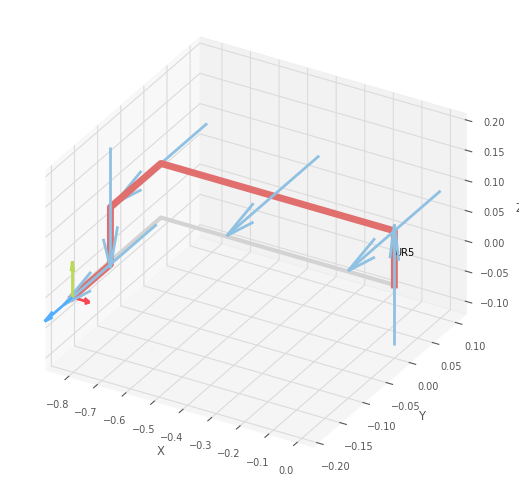

<Figure size 640x480 with 0 Axes>

In [646]:
q_start =[0,0,0,0,0,0]
print("q_start=",np.rad2deg(q_start))
robot.plot(q_start)
plt.show()

- Final joint configurations

q_end= [180.   0.   0.  90.   0.   0.]


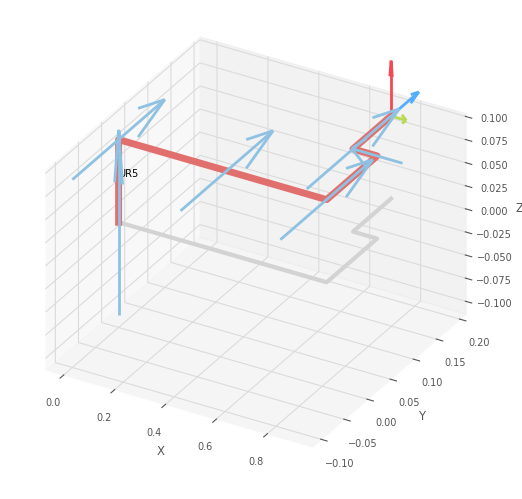

<Figure size 640x480 with 0 Axes>

In [647]:
q_end=[math.pi, 0, 0, math.pi/2, 0, 0]
print("q_end=",np.rad2deg(q_end))
robot.plot(q_end)
plt.show()

#### **4.Plan the trajectory with prebuilt function**

In [648]:
N=100
t_start=0
t_stop=5
t_shag=t_stop/N
time=np.arange(t_start,t_stop,t_shag)
tr=rtb.jtraj(q_start,q_end,time)
#print("q shape :",tr.q.shape)
#print("qd shape :",tr.qd.shape)
#print("qdd shape :",tr.qdd.shape)


#time

- Plot $q,\dot{q} ,\ddot{q}$ for each links : 

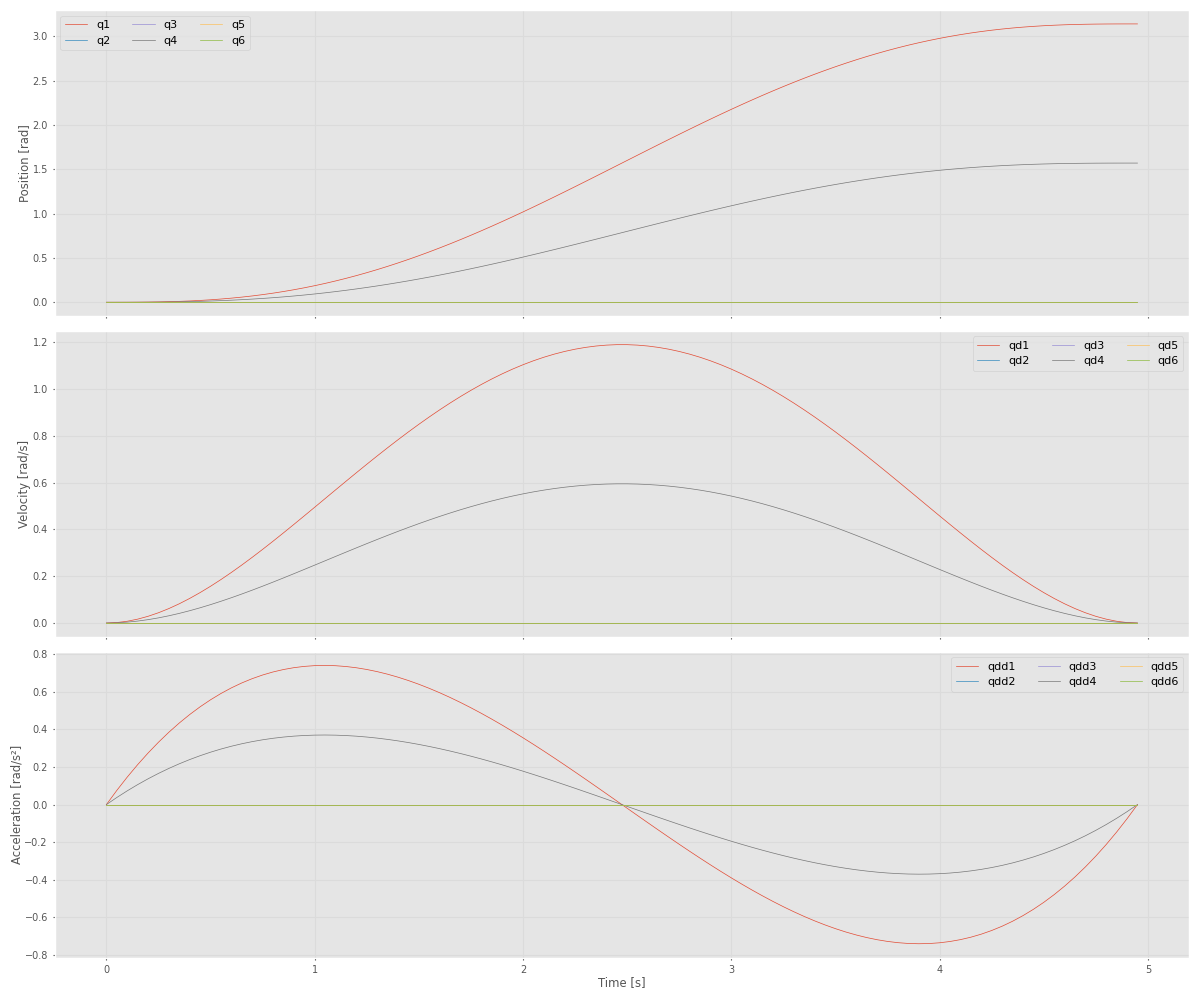

In [649]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for j in range(robot.n):
    axes[0].plot(time, tr.q[:, j], label=f"q{j+1}")
    axes[1].plot(time, tr.qd[:, j], label=f"qd{j+1}")
    axes[2].plot(time, tr.qdd[:, j], label=f"qdd{j+1}")

axes[0].set_ylabel("Position [rad]")
axes[1].set_ylabel("Velocity [rad/s]")
axes[2].set_ylabel("Acceleration [rad/s²]")
axes[2].set_xlabel("Time [s]")

for ax in axes:
    ax.grid(True)

axes[0].legend(ncol=3, fontsize=8)
axes[1].legend(ncol=3, fontsize=8)
axes[2].legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

#### **5.Solve the inverse dynamics**

The inverse dynamics equation is given for each statuation :

1-Non-zero velocities and accelerations : $\dot{q} \ne 0,\quad \ddot{q} \ne 0$
 $$\tau_{all}=M(q)\ddot{q}+C(q,\dot{q})\dot{q}+G(q)$$

2- non-zero velocities and negligible accelerations : $\dot{q} \ne 0,\quad \ddot{q} \approx 0$
 $$\tau_{quasi}=C(q,\dot{q})\dot{q}+G(q)$$

3- zero velocities and accelerations : $\dot{q} = 0,\quad \ddot{q} = 0$

 $$\tau_{hold}=G(q)$$
 

In [650]:
tau_all=robot.rne(tr.q,tr.qd,tr.qdd)
tau_quasi=robot.rne(tr.q,tr.qd,np.zeros_like(tr.qdd))
tau_hold=robot.rne(tr.q,np.zeros_like(tr.qd),np.zeros_like(tr.qdd))

#print("tau_all shape :",tau_all.shape)
#print("tau_quasi shape :",tau_quasi.shape)
#print("tau_hold shape :",tau_hold.shape)


#### **6. Obtain the components of the dynamic equation**

In [651]:
M=robot.inertia(tr.q)
C=robot.coriolis(tr.q,tr.qd)
G=robot.gravload(tr.q)


In [652]:
sample_ids = [0, len(time)//2, len(time)-1]

for k in sample_ids:
    print("="*60)
    print("time =", time[k])
    print("M(q) =")
    print(M[k])
    print("C(q, qd) =")
    print(C[k])
    print("G(q) =")
    print(G[k])

time = 0.0
M(q) =
[[ 5.51043568e+00  2.19194568e-02  2.19194568e-02  1.85194568e-02
  -6.51622249e-03  6.12323400e-21]
 [ 2.19194568e-02  5.36709439e+00  1.22032514e+00  1.39180105e-02
  -3.15593720e-03  1.00000000e-04]
 [ 2.19194568e-02  1.22032514e+00  2.49614085e+00  1.39180105e-02
  -3.15593720e-03  1.00000000e-04]
 [ 1.85194568e-02  1.39180105e-02  1.39180105e-02  2.26098811e-01
  -3.15593720e-03  1.00000000e-04]
 [-6.51622249e-03 -3.15593720e-03 -3.15593720e-03 -3.15593720e-03
   2.15019315e-01  6.12323400e-21]
 [ 6.12323400e-21  1.00000000e-04  1.00000000e-04  1.00000000e-04
   6.12323400e-21  2.12280800e-01]]
C(q, qd) =
[[0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]]
G(q) =
[ 3.94430453e-31 -5.19971008e+01 -1.48182309e+01  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
time = 2.5
M(q) =
[[ 5.35118395e+00  1.62990142e-02  1.62990142e-02  1.28990142e-02
  -4.53862376e-03  6.12323400e-21]
 [ 1.6299014

In [653]:
summary = pd.DataFrame({
    "time [s]": time,
    "||M(q)||_F": [np.linalg.norm(M[k], ord="fro") for k in range(N)],
    "||C(q,qd)||_F": [np.linalg.norm(C[k], ord="fro") for k in range(N)],
    "||G(q)||_2": [np.linalg.norm(G[k], ord=2) for k in range(N)],
})
summary.head(10)

,time [s],||M(q)||_F,"||C(q,qd)||_F",||G(q)||_2
0,0.00,8.278022,0.000000,54.067351
1,0.05,8.278016,0.000593,54.067324
2,0.10,8.277974,0.002324,54.067136
3,0.15,8.277861,0.005122,54.066637
4,0.20,8.277645,0.008917,54.065685
5,0.25,8.277297,0.013640,54.064148
6,0.30,8.276788,0.019225,54.061902
7,0.35,8.276094,0.025605,54.058835
8,0.40,8.275190,0.032715,54.054841
9,0.45,8.274054,0.040492,54.049825


#### **7. Joint torque plots for the three scenarios**

The following plots compare the joint torques for full dynamics, quasi-static motion, and static holding.

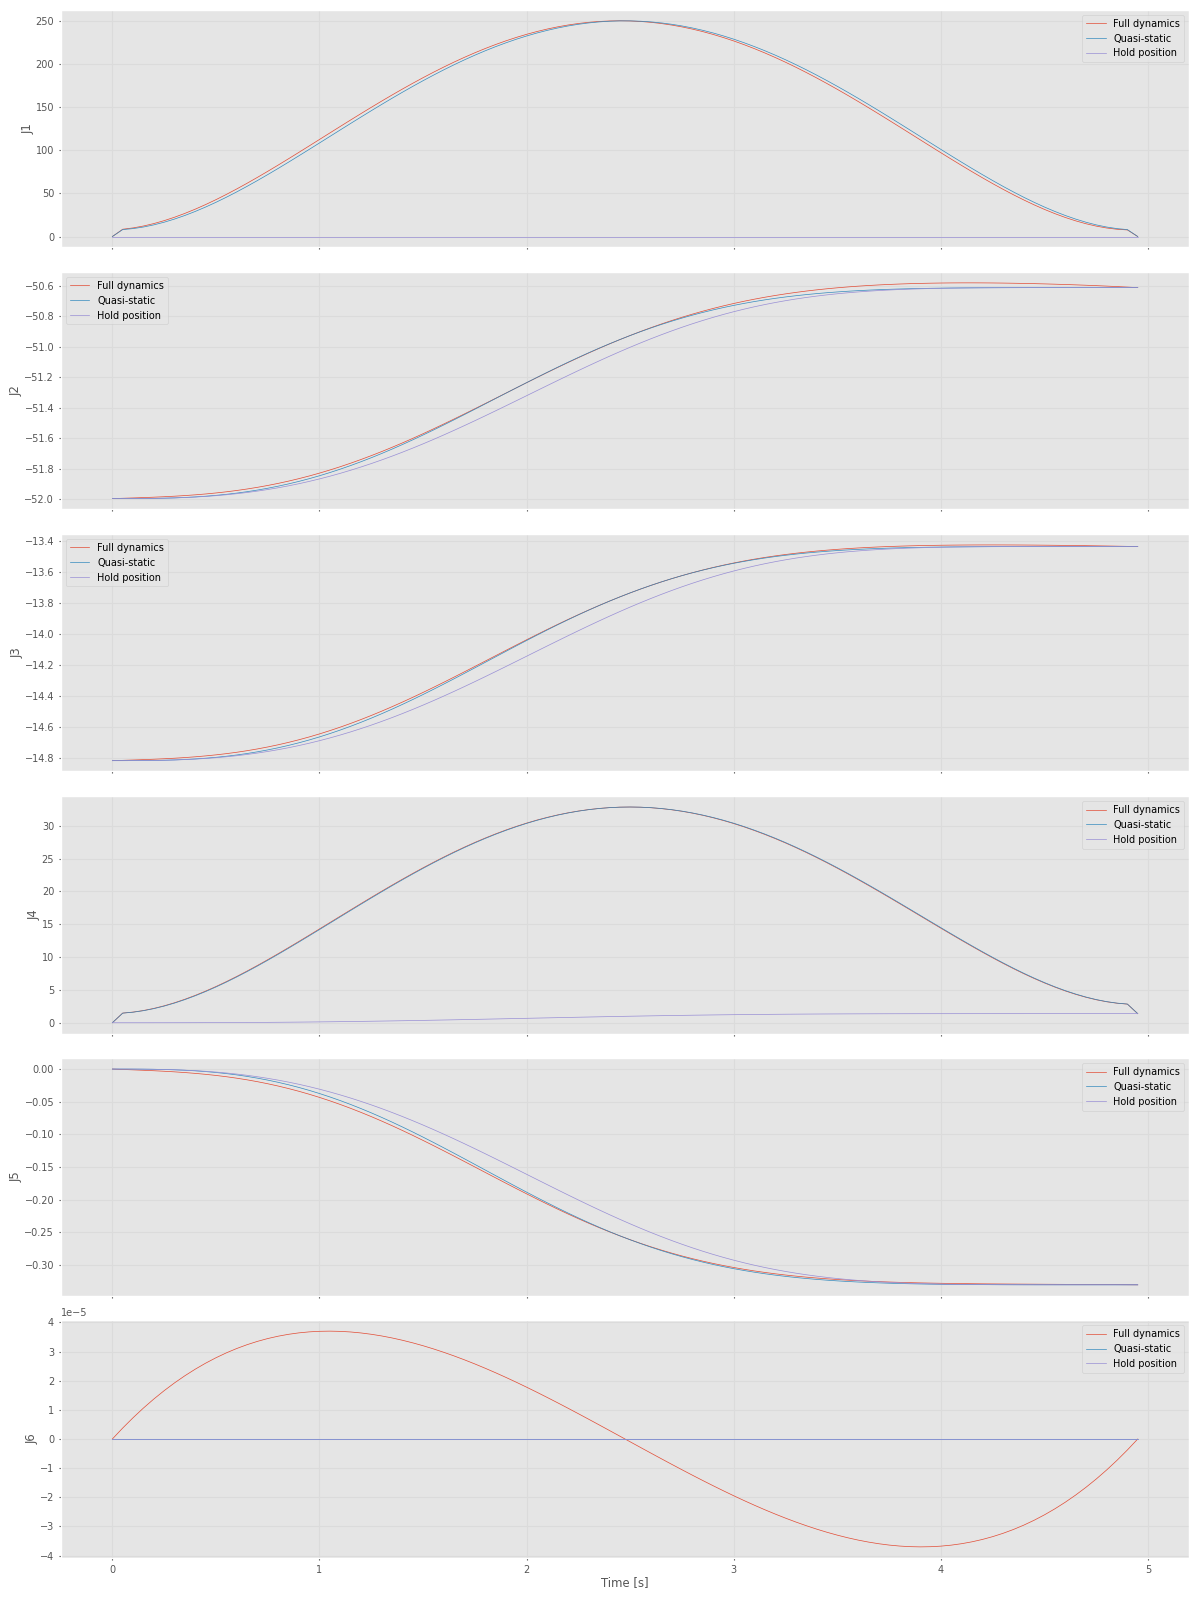

In [654]:
fig, axes = plt.subplots(robot.n, 1, figsize=(12, 16), sharex=True)

for j in range(robot.n):
    axes[j].plot(time, tau_all[:, j], label="Full dynamics")
    axes[j].plot(time, tau_quasi[:, j], label="Quasi-static")
    axes[j].plot(time, tau_hold[:, j], label="Hold position")
    axes[j].set_ylabel(f"J{j+1}")
    axes[j].grid(True)
    axes[j].legend()

axes[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

In [655]:
torque_stats = pd.DataFrame({
    "Joint": np.arange(1, robot.n + 1),
    "max |tau_full|": np.max(np.abs(tau_all), axis=0),
    "max |tau_quasi|": np.max(np.abs(tau_quasi), axis=0),
    "max |tau_hold|": np.max(np.abs(tau_hold), axis=0),
})
torque_stats

,Joint,max |tau_full|,max |tau_quasi|,max |tau_hold|
0,1,250.400699,2.502998e+02,6.067066e-16
1,2,51.997101,5.199710e+01,5.199710e+01
2,3,14.818231,1.481823e+01,1.481823e+01
3,4,32.851362,3.285381e+01,1.383801e+00
4,5,0.330539,3.305388e-01,3.305388e-01
5,6,0.000037,1.355253e-20,0.000000e+00


# Conclusions

The UR5 manipulator model was loaded from the Robotics Toolbox and its Denavit–Hartenberg parameters were displayed. The link masses, centers of mass, inertia-related quantities, drive inertias, viscous friction coefficients, Coulomb friction coefficients, gear ratios, and joint limits were organized in a parameter table.

Two arbitrary joint configurations were defined and connected by a joint-space trajectory. The inverse dynamics problem was solved using the recursive Newton–Euler method for three scenarios: full dynamic motion, quasi-static motion, and static holding.

The matrices $M(q)$, $C(q,\dot q)$, and $G(q)$ were computed numerically along the trajectory, and the torque profiles for all joints were plotted. The results illustrate the contributions of inertia, Coriolis/centrifugal effects, and gravity to the required joint torques.